Les données .dat sont générées à l'aide du code "lubrification_thetafix_alpha2_betagoal.edp" lancé en FreeFem.

Régression log-log pour otbenir la pente des coefficients en fontions de $\frak{d}$. Ici, la condition au bord pour $v^{\circlearrowleft} $ 
était sur la boule $v_{|\partial B}(x,y) = (-(y-V_B), x-U_B)$ où $(U_B, V_B)$ est le centre de la particule. On devrait normalement avoir un exposant $A_{33}$ en $O(\frak{d}^{-1/2})$.


frak_d : min=0.0551, max=1.3000, N=19

seuil      A11      A13      A33      A22
----------------------------------------
0.050    nan    nan    nan    nan
0.100    nan    nan    nan    nan
0.150    -0.572    -0.806    -0.947    -1.611
0.200    -0.567    -0.805    -0.949    -1.614
0.300    -0.556    -0.794    -0.939    -1.610
1.300    -0.471    -0.674    -0.763    -1.478
théorie   -0.500    (?)      -0.500      -1.5


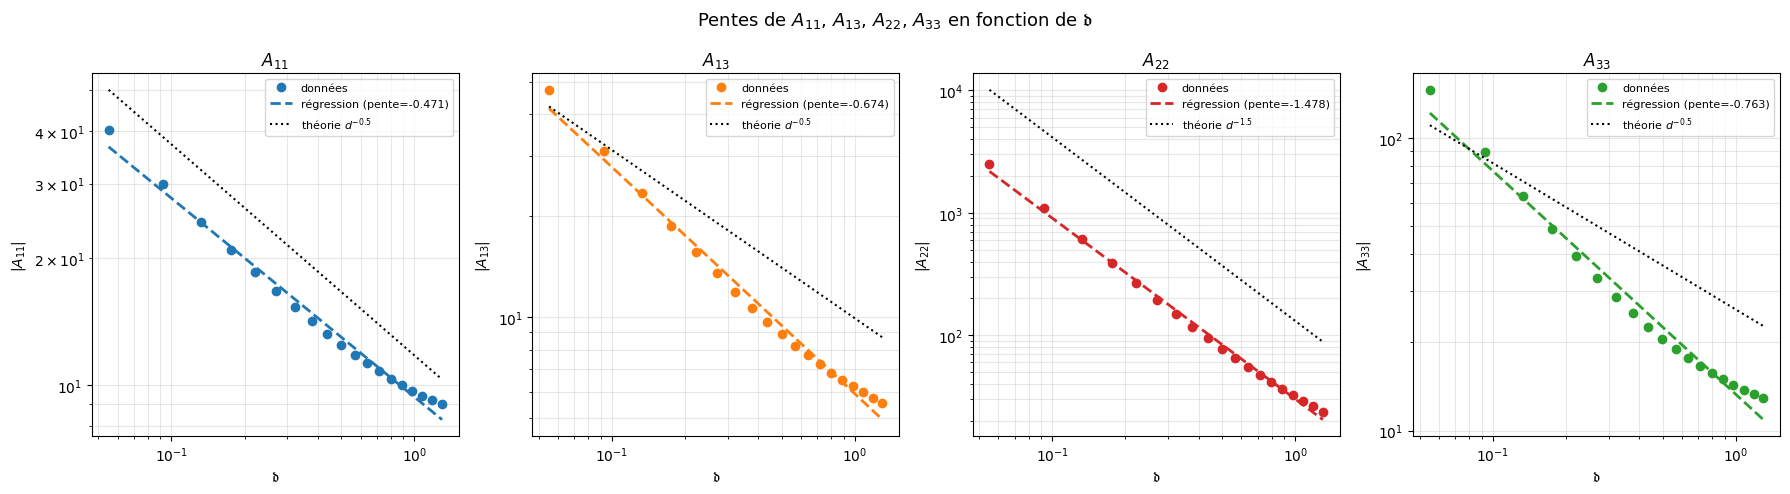

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


#Etape 1 : chargement des données.
d_canal = 6.0
a       = 1.0
b_axis  = 0.5
theta   = 0.0
yext    = np.sqrt((a*np.sin(theta))**2 + (b_axis*np.cos(theta))**2)

data    = np.loadtxt("lubrification_alpha2_theta0pi.dat")
dist_FF = data[:, 0] # 1 - Yc/d avec Yc qu'on a fait varier
A11     = data[:, 2]
A13     = data[:, 4]
A33     = data[:, 7]
A22     = data[:,5]
idx     = np.argsort(dist_FF)
dist_FF = dist_FF[idx]
A11     = A11[idx]; A13 = A13[idx]; A33 = A33[idx]; A22=A22[idx]

frak_d  = d_canal * dist_FF - yext # d - (Y +b) si \theta =0
mask    = frak_d > 1e-6
frak_d  = frak_d[mask]
A11     = A11[mask]; A13 = A13[mask]; A33 = A33[mask]; A22 = A22[mask]

print(f"frak_d : min={frak_d.min():.4f}, max={frak_d.max():.4f}, N={len(frak_d)}")

def pente_prefacteur(d, v, seuil):
    m = (d > 0) & (d <= seuil) & (np.abs(v) > 1e-14)
    if m.sum() < 3:
        return float('nan'), float('nan')
    sl, ic, _, _, _ = linregress(np.log(d[m]), np.log(np.abs(v[m])))
    return sl, np.exp(ic)

seuils = [0.05, 0.10, 0.15, 0.20, 0.30, frak_d.max()]
print(f"\nseuil      A11      A13      A33      A22")
print("-" * 40)
for s in seuils:
    p11, _ = pente_prefacteur(frak_d, A11, s)
    p13, _ = pente_prefacteur(frak_d, A13, s)
    p33, _ = pente_prefacteur(frak_d, A33, s)
    p22, _ = pente_prefacteur(frak_d, A22, s)
    print(f"{s:.3f}    {p11:.3f}    {p13:.3f}    {p33:.3f}    {p22:.3f}")
print(f"théorie   -0.500    (?)      -0.500      -1.5")

##################################################################
##           FIGURES
##################################################################
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(r"Pentes de $A_{11}$, $A_{13}$, $A_{22}$, $A_{33}$ en fonction de $\mathfrak{d}$", fontsize=13)

# Grille théorique
d_th = np.logspace(np.log10(frak_d.min()), np.log10(frak_d.max()), 300)
seuil_fig = frak_d.max()

for ax, vals, label, color, ref_pente in [
    (axes[0], A11, r"$A_{11}$", "C0", -0.5),
    (axes[1], A13, r"$A_{13}$", "C1", -0.5),
    (axes[2], A22, r"$A_{22}$", "C3", -1.5),
    (axes[3], A33, r"$A_{33}$", "C2", -0.5),
]:
    sl, pf = pente_prefacteur(frak_d, vals, seuil_fig)

    ax.loglog(frak_d, np.abs(vals), 'o', color=color, ms=6, label="données")

    if not np.isnan(sl):
        ax.loglog(d_th, pf * d_th**sl, '--', color=color, lw=2,
                  label=f"régression (pente={sl:.3f})")

    ref = np.abs(vals).mean() * frak_d.mean()**(-ref_pente)
    ax.loglog(d_th, ref * d_th**ref_pente, ':', color='black', lw=1.5,
              label=f"théorie $d^{{{ref_pente}}}$")

    ax.set_xlabel(r"$\mathfrak{d}$")
    ax.set_ylabel(f"|{label}|")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

Régression log-log pour otbenir la pente des coefficients en fontions de $\frak{d}$. Ici, la condition au bord pour $v^{\circlearrowleft} $ 
était sur la boule $v_{|\partial B}(x,y) = (-y, x-U_B)$ où $(U_B, V_B)$ est le centre de la particule. On devrait normalement avoir un exposant $A_{33}$ en $O(\frak{d}^{-1/2})$.

frak_d : min=0.0551, max=1.3000, N=19

seuil      A11      A13      A33      A22
----------------------------------------
0.050    nan    nan    nan    nan
0.100    nan    nan    nan    nan
0.150    -0.572    -0.538    -0.535    -1.611
0.200    -0.567    -0.538    -0.537    -1.614
0.300    -0.556    -0.536    -0.541    -1.610
1.300    -0.471    -0.521    -0.580    -1.478
théorie   -0.500    (?)      -0.500      -1.5


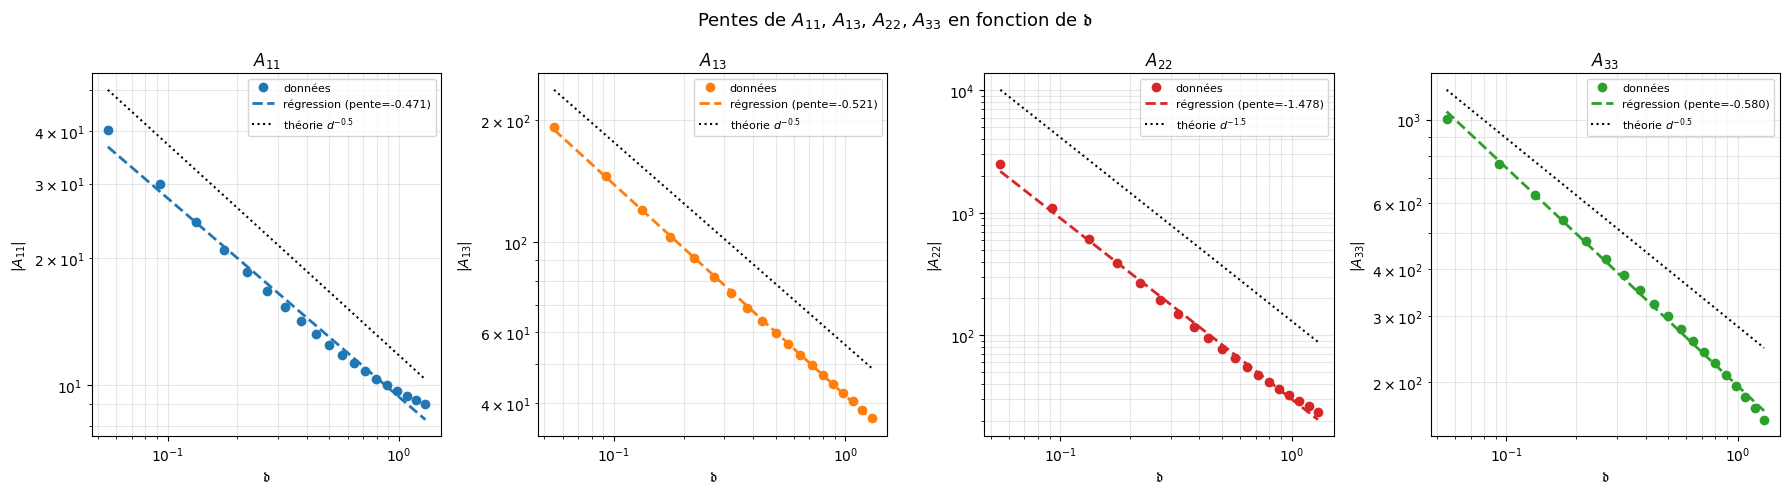

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


#Etape 1 : chargement des données.
d_canal = 6.0
a       = 1.0
b_axis  = 0.5
theta   = 0.0
yext    = np.sqrt((a*np.sin(theta))**2 + (b_axis*np.cos(theta))**2)

data    = np.loadtxt("lubrification_alpha2_theta0pi_Yrot0.dat")
dist_FF = data[:, 0] # 1 - Yc/d avec Yc qu'on a fait varier
A11     = data[:, 2]
A13     = data[:, 4]
A33     = data[:, 7]
A22     = data[:,5]
idx     = np.argsort(dist_FF)
dist_FF = dist_FF[idx]
A11     = A11[idx]; A13 = A13[idx]; A33 = A33[idx]; A22=A22[idx]

frak_d  = d_canal * dist_FF - yext # d - (Y +b) si \theta =0
mask    = frak_d > 1e-6
frak_d  = frak_d[mask]
A11     = A11[mask]; A13 = A13[mask]; A33 = A33[mask]; A22 = A22[mask]

print(f"frak_d : min={frak_d.min():.4f}, max={frak_d.max():.4f}, N={len(frak_d)}")

def pente_prefacteur(d, v, seuil):
    m = (d > 0) & (d <= seuil) & (np.abs(v) > 1e-14)
    if m.sum() < 3:
        return float('nan'), float('nan')
    sl, ic, _, _, _ = linregress(np.log(d[m]), np.log(np.abs(v[m])))
    return sl, np.exp(ic)

seuils = [0.05, 0.10, 0.15, 0.20, 0.30, frak_d.max()]
print(f"\nseuil      A11      A13      A33      A22")
print("-" * 40)
for s in seuils:
    p11, _ = pente_prefacteur(frak_d, A11, s)
    p13, _ = pente_prefacteur(frak_d, A13, s)
    p33, _ = pente_prefacteur(frak_d, A33, s)
    p22, _ = pente_prefacteur(frak_d, A22, s)
    print(f"{s:.3f}    {p11:.3f}    {p13:.3f}    {p33:.3f}    {p22:.3f}")
print(f"théorie   -0.500    (?)      -0.500      -1.5")

##################################################################
##           FIGURES
##################################################################
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(r"Pentes de $A_{11}$, $A_{13}$, $A_{22}$, $A_{33}$ en fonction de $\mathfrak{d}$", fontsize=13)

# Grille théorique
d_th = np.logspace(np.log10(frak_d.min()), np.log10(frak_d.max()), 300)
seuil_fig = frak_d.max()

for ax, vals, label, color, ref_pente in [
    (axes[0], A11, r"$A_{11}$", "C0", -0.5),
    (axes[1], A13, r"$A_{13}$", "C1", -0.5),
    (axes[2], A22, r"$A_{22}$", "C3", -1.5),
    (axes[3], A33, r"$A_{33}$", "C2", -0.5),
]:
    sl, pf = pente_prefacteur(frak_d, vals, seuil_fig)

    ax.loglog(frak_d, np.abs(vals), 'o', color=color, ms=6, label="données")

    if not np.isnan(sl):
        ax.loglog(d_th, pf * d_th**sl, '--', color=color, lw=2,
                  label=f"régression (pente={sl:.3f})")

    ref = np.abs(vals).mean() * frak_d.mean()**(-ref_pente)
    ax.loglog(d_th, ref * d_th**ref_pente, ':', color='black', lw=1.5,
              label=f"théorie $d^{{{ref_pente}}}$")

    ax.set_xlabel(r"$\mathfrak{d}$")
    ax.set_ylabel(f"|{label}|")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()